# **1) Input**

- The input for the method must be a MAF (Mutation Annotation Format) file, a tab-delimited file containing mutations from tumor samples.

- The MAF columns utilized in this analysis are listed in the "maf_columns" object within the "Read input files" section.


<br>

### **Upload file**

* Run the cell below and upload the MAF file using the button shown in the cell output.

* After uploading the input datasets, run the next cells.



In [ ]:
from google.colab import files
uploaded_maf_file = files.upload()
maf_file_name = list(uploaded_maf_file.keys())[0]


Saving dlbcl_integrated_mafs.tsv to dlbcl_integrated_mafs.tsv


<br><br><br>
<br><br><br>

---


# **2) Setup**



<br>

### **Import libraries**

In [ ]:
!pip install causal-learn==0.1.4.4

import os
import copy
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import fisher_exact

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

import pydot
import re

from IPython.display import SVG
from IPython.display import SVG, display

from causallearn.utils.GraphUtils import GraphUtils
from causallearn.graph.GeneralGraph import GeneralGraph


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.8/191.8 kB 2.4 MB/s eta 0:00:00


<br>

### **Create folders**

In [ ]:
# Output folders
dirs = {
    "datasets": "Datasets",
    "tables": "Output/Tables",
    "graphs": "Output/Graphs",
    "gene_networks": "Output/Gene networks"
}

# Create the output folders for path in dirs.values():
for path in dirs.values():
    os.makedirs(path, exist_ok=True)
    print(f"Directory '{path}' created or already exists.")


Directory 'Datasets' created or already exists.
Directory 'Output/Tables' created or already exists.
Directory 'Output/Graphs' created or already exists.
Directory 'Output/Gene networks' created or already exists.


<br>

### **Load files**

* The files with driver genes are automatically downloaded from the repository.

In [ ]:
# Load the canonical driver genes file
canonical_drivers_file_name = "ncg_canonical_cancer_drivers.csv"
!wget -O {dirs["datasets"] + "/" + canonical_drivers_file_name} https://raw.githubusercontent.com/paulo-ribeiro/datasets/refs/heads/main/ncg_canonical_cancer_drivers.csv

# Load the customized gene panel file
customized_gene_panel_file_name = "customized_gene_panel-Identification_somatic_variants_in_ctDNA.csv"
!wget -O {dirs["datasets"] + "/" + customized_gene_panel_file_name} https://raw.githubusercontent.com/paulo-ribeiro/datasets/refs/heads/main/customized_gene_panel-Identification_somatic_variants_in_ctDNA_2.csv

# Load the candidate cancer drivers file
candidate_drivers_file_name = "ncg_candidate_drivers_updated.csv"
!wget -O {dirs["datasets"] + "/" + candidate_drivers_file_name} https://raw.githubusercontent.com/paulo-ribeiro/datasets/refs/heads/main/ncg_candidate_drivers_updated.csv

# Load file with oncogene (OG) and tumor suppressor (TSG) information.
og_tsg_file_name = "ncg_cancerdrivers_annotation_supporting_evidence.tsv"
!wget -O {dirs["datasets"] + "/" + og_tsg_file_name} https://raw.githubusercontent.com/paulo-ribeiro/datasets/refs/heads/main/ncg_cancerdrivers_annotation_supporting_evidence.tsv

# Load file with the DLBCL gene network of the paper "Genetic and Functional Drivers of Diffuse Large B Cell Lymphoma" (Reddy, 2017)
dlbcl_gene_network_file_name = "dlbcl_gene_network-reddy2017.tsv"
!wget -O {dirs["datasets"] + "/" + dlbcl_gene_network_file_name} https://raw.githubusercontent.com/paulo-ribeiro/datasets/refs/heads/main/dlbcl_gene_network-reddy2017.tsv

# Load file with the DLBCL genetic subtypes of the paper "A probabilistic classification tool for genetic subtypes of diffuse large B cell lymphoma with therapeutic implications" (Wright, 2020)
dlbcl_genetic_subtypes_file_name = "dlbcl_genetic_subtypes-wright2020.tsv"
!wget -O {dirs["datasets"] + "/" + dlbcl_genetic_subtypes_file_name} https://raw.githubusercontent.com/paulo-ribeiro/datasets/refs/heads/main/dlbcl_genetic_subtypes-wright2020.tsv



--2026-05-28 20:11:22--  https://raw.githubusercontent.com/paulo-ribeiro/datasets/refs/heads/main/ncg_canonical_cancer_drivers.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3437 (3.4K) [text/plain]
Saving to: ‘Datasets/ncg_canonical_cancer_drivers.csv’

Datasets/ncg_canoni 100%[===================>]   3.36K  --.-KB/s    in 0s      

2026-05-28 20:11:22 (36.8 MB/s) - ‘Datasets/ncg_canonical_cancer_drivers.csv’ saved [3437/3437]

--2026-05-28 20:11:22--  https://raw.githubusercontent.com/paulo-ribeiro/datasets/refs/heads/main/customized_gene_panel-Identification_somatic_variants_in_ctDNA_2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (

<br><br><br>
<br><br><br>

---


# **3) Utility functions**

<br>

### **Plot causal graph**

In [ ]:
def plot_causal_graph(cg, file_name="causal_graph", canonical_drivers=None, candidate_drivers=None,
                      oncogene=None, tsg=None, legend=None, remove_unconnected_nodes=True,
                      display_graph=True, nodesep=0.5, ranksep=0.5):

    if isinstance(cg, GeneralGraph):
        # Convert a graph object to a DOT object
        cg_dot = GraphUtils.to_pydot(cg)
        # Map with gene index and its name
        original_nodes = cg.get_nodes()
        node_map = {i: node.get_name() for i, node in enumerate(original_nodes)}
    elif isinstance(cg, pydot.Dot):
        cg_dot = copy.deepcopy(cg)
    else:
        raise ValueError("You need to provide a valid 'cg' object.")


    # Collect all nodes that appear in edges
    connected_nodes = set()
    for edge in cg_dot.get_edges():
        connected_nodes.add(edge.get_source())
        connected_nodes.add(edge.get_destination())
    connected_nodes = {str(x) for x in connected_nodes}


    for node in cg_dot.get_nodes():
        # Setting the node font
        node.set_fontname("Helvetica")

        # Get the name of the gene
        node_name = node_map.get(int(node.get_name())) if isinstance(cg, GeneralGraph) else node.get_attributes()['label'].strip('"')

        node.set_style("filled")
        node.set_color("transparent")

        # Coloring the nodes that are canonical/candidate driver genes
        if (canonical_drivers is not None) and (node_name in canonical_drivers):
            node.set_fillcolor("#9B59B6")
            node.set_fontcolor("white")
        elif (candidate_drivers is not None) and (node_name in candidate_drivers):
            node.set_fillcolor("#D9BDE1")
            node.set_fontcolor("#562E67")
        elif node_name.startswith("<<table"):
            node.set_shape("plaintext")
        else:
            node.set_fillcolor("#CCCCCC")
            node.set_fontcolor("#484848")


        # Defining the shape of the node (oncogene or tumor suppressor)
        if (oncogene is not None) and (node_name in oncogene):
            node.set_shape("box")
        elif (tsg is not None) and (node_name in tsg):
            node.set_shape("hexagon")


        # Remove nodes that are not connected
        if (remove_unconnected_nodes) and (node.get_name() not in connected_nodes):
            cg_dot.del_node(node.get_name())


    # Adding the legend to the graph
    if (legend is not None):
        legend_node = create_legend(legend)
        cg_dot.add_node(legend_node)

    # Saving the graph
    cg_dot.set_graph_defaults(dpi="200", nodesep=str(nodesep), ranksep=str(ranksep))
    cg_dot.write_png(file_name + ".png")
    cg_dot.write_pdf(file_name + ".pdf")

    print(f"Causal graph saved to '{file_name}'\n")

    # Visualizing the graph
    if (display_graph):
        cg_dot.set_graph_defaults(dpi="60", nodesep=str(nodesep), ranksep=str(ranksep))
        img_svg = SVG(cg_dot.create_svg())
        print("\n\n")
        display(img_svg)


<br>

### **Create graph legend**

In [ ]:
def create_legend(items):
    rows = ""
    for color, desc in items:
        rows += f"<tr><td width='20' bgcolor='{color}'></td><td align='left'>{desc}</td></tr>"

    legend_html = f"<<table border='0' cellborder='0' cellspacing='0' cellpadding='3'>{rows}</table>>"

    legend_node = pydot.Node("legend", shape="plaintext", label=legend_html)
    legend_node.set_fontname("Helvetica")

    return legend_node


<br>

### **Print MAF information**


In [ ]:
def print_title(title): print("\n", title, "\n", "="*len(title), sep="")

def print_inf_maf_data(maf_df):
    # Obtaining all unique tumor samples from MAF
    num_unique_samples = maf_df["Tumor_Sample_Barcode"].unique()

    # Obtaining all unique mutations from MAF
    num_unique_genes = maf_df["Hugo_Symbol"].unique()

    # Create the DataFrame with the number of mutations in each tumor sample
    number_mutations_df = maf_df.groupby("Tumor_Sample_Barcode").size().reset_index(name="Number of mutations")
    number_mutations_df = number_mutations_df.rename(columns={"Tumor_Sample_Barcode": "Sample"})

    # Calculate the mean and median of the number of mutations per sample
    mean_mutations = number_mutations_df["Number of mutations"].mean()
    median_mutations = number_mutations_df["Number of mutations"].median()

    # Print the results
    print_title("Information from the MAF data:")
    print(f"   Total mutations: {len(maf_df)}")
    print(f"   Number of unique tumor samples: {len(num_unique_samples)}")
    print(f"   Number of unique genes: {len(num_unique_genes)}")
    print(f"   Mean number of mutations per sample: {mean_mutations:.0f}")
    print(f"   Median number of mutations per sample: {median_mutations:.0f}")


<br><br><br>
<br><br><br>

---


# **4) Read files**



<br>

### **MAF**

- In this section, we read the MAF file and create a DataFrame containing only the columns used in this analysis.

- We also calculate the Variant Allele Frequency (VAF) of each mutation from the MAF and insert it into the DataFrame.

- Note: The VAF indicates the proportion of a variant allele in a gene in the cells of a sample.

In [ ]:
# MAF columns that will be in the dataframe
maf_columns = ["Hugo_Symbol", "Variant_Classification", "Variant_Type", "Tumor_Sample_Barcode"]

# Create the dataframe ignoring comment lines
maf_df = pd.read_csv(maf_file_name, sep="\t", usecols=maf_columns, comment="#")

print_inf_maf_data(maf_df)
print("\n\n")
display(maf_df)



Information from the MAF data:
   Total mutations: 62128
   Number of unique tumor samples: 1636
   Number of unique genes: 13585
   Mean number of mutations per sample: 38
   Median number of mutations per sample: 8





,Hugo_Symbol,Variant_Classification,Variant_Type,Tumor_Sample_Barcode
0,C8orf4,Missense_Mutation,SNP,DLBCL-DFCI_DLBCL_Goe05
1,SLC27A1,Nonsense_Mutation,SNP,DLBCL-DFCI_DLBCL_Goe05
2,HS3ST1,Missense_Mutation,SNP,DLBCL-DFCI_DLBCL_Goe05
3,FAF2,Nonsense_Mutation,SNP,DLBCL-DFCI_DLBCL_Goe05
4,PTPRC,Silent,SNP,DLBCL-DFCI_DLBCL_Goe05
...,...,...,...,...
62123,ZBTB43,3'Flank,SNP,TCGA-VB-A8QN-01
62124,RAB9A,3'UTR,SNP,TCGA-VB-A8QN-01
62125,IGLJ3,5'UTR,DEL,TCGA-FF-8042-01
62126,IGKJ2,In_Frame_Del,DEL,TCGA-FF-8042-01


<br>


### **Customized gene panel**


In [ ]:
customized_gene_panel_df = pd.read_csv(dirs["datasets"] + "/" + customized_gene_panel_file_name).iloc[:,0].to_list()
print(f"   Number of genes in the customized panel: {len(customized_gene_panel_df)}")


   Number of genes in the customized panel: 237


<br>


### **Canonical drivers**


In [ ]:
canonical_cancer_drivers = pd.read_csv(dirs["datasets"] + "/" + canonical_drivers_file_name).iloc[:,0].to_list()
print(f"   Number of canonical cancer drivers genes: {len(canonical_cancer_drivers)}")


   Number of canonical cancer drivers genes: 591


<br>


### **Candidate drivers**

In [ ]:
candidate_cancer_drivers = pd.read_csv(dirs["datasets"] + "/" + candidate_drivers_file_name).iloc[:,0].to_list()
print(f"   Number of candidate cancer drivers genes: {len(candidate_cancer_drivers)}")


   Number of candidate cancer drivers genes: 2756


<br>


### **OG and TSG**

In [ ]:
og_tsg_genes = pd.read_csv(dirs["datasets"] + "/" + og_tsg_file_name, sep="\t", usecols=["symbol", "NCG_oncogene", "NCG_tsg"])

# Generate the list of unique oncogenes
oncogene_list = og_tsg_genes[og_tsg_genes["NCG_oncogene"] == 1]["symbol"].unique().tolist()

# Generate the list of unique tumor suppressor genes
tsg_list = og_tsg_genes[og_tsg_genes["NCG_tsg"] == 1]["symbol"].unique().tolist()

print(f"Number of unique Oncogenes (OG): {len(oncogene_list)}")
print(f"Number of unique Tumor Suppressor Genes (TSG): {len(tsg_list)}")


Number of unique Oncogenes (OG): 256
Number of unique Tumor Suppressor Genes (TSG): 254


<br>


### **DLBCL gene network**

In [ ]:
# Read file with the DLBCL gene network of the paper "Genetic and Functional Drivers of Diffuse Large B Cell Lymphoma" (Reddy, 2017)
dlbcl_gene_network_df = pd.read_csv(dirs["datasets"] + "/" + dlbcl_gene_network_file_name, sep="\t")

# Formatting of the DLBCL gene network data
dlbcl_gene_network_df["EdgeType"] = dlbcl_gene_network_df["EdgeType"].replace({
    "exclusion": "Mutual exclusivity",
    "overlap": "Co-occurrence"
})

num_genes = pd.concat([dlbcl_gene_network_df["Gene1"], dlbcl_gene_network_df["Gene2"]]).nunique()
print(f"   Number of nodes in the network: {num_genes}")
print(f"   Number of edges in the network: {len(dlbcl_gene_network_df)}")


   Number of nodes in the network: 54
   Number of edges in the network: 121


<br>


### **DLBCL subtypes**

In [ ]:
# Read file with the DLBCL genetic subtypes of the paper "A probabilistic classification tool for genetic subtypes of diffuse large B cell lymphoma with therapeutic implications" (Wright, 2020)
dlbcl_genetic_subtypes_df = pd.read_csv(dirs["datasets"] + "/" + dlbcl_genetic_subtypes_file_name, sep="\t")

print(f"   Number of genes in the file: {len(dlbcl_genetic_subtypes_df["Gene"].unique())}")
print(f"   Number of subtypes in the file: {len(dlbcl_genetic_subtypes_df["Subtype"].unique())}")



   Number of genes in the file: 165
   Number of subtypes in the file: 6


<br><br><br>
<br><br><br>

---


# **5) Data preprocessing**

<br>

### **Filter mutations**

  - Filtering MAF mutations according to the following criteria:

    - Removal of mutations with missing values in critical columns.

    - Selection of only single nucleotide variants (SNVs).

    - Filtering based on tumor and normal read depth and allele counts.

    - Selection of only non-silent mutations with potential functional impact.


In [ ]:
#  Remove rows with missing values in critical columns
critical_columns = ["Hugo_Symbol"]
maf_df.dropna(subset=critical_columns, inplace=True)

# Filter for non-silent mutations
non_silent_mutations = [
    "Frame_Shift_Del", "Frame_Shift_Ins", "In_Frame_Del", "In_Frame_Ins",
    "Missense_Mutation", "Nonsense_Mutation", "Nonstop_Mutation",
    "Splice_Site", "Translation_Start_Site"
]
maf_df = maf_df[maf_df["Variant_Classification"].isin(non_silent_mutations)]

print_inf_maf_data(maf_df)



Information from the MAF data:
   Total mutations: 48409
   Number of unique tumor samples: 1634
   Number of unique genes: 11412
   Mean number of mutations per sample: 30
   Median number of mutations per sample: 8


<br>

### **Filter hypermutated samples**

  - Hypermutated samples should be excluded as they are often noisy outliers, which can distort analyses of clustering methods.


In [ ]:
# Count mutations per sample
mutations_per_sample = maf_df["Tumor_Sample_Barcode"].value_counts()

# Calculate Q1, Q3 and IQR
Q1 = mutations_per_sample.quantile(0.25)
Q3 = mutations_per_sample.quantile(0.75)
IQR = Q3 - Q1
threshold = min(Q3 + 4.5 * IQR, 600)

# Remove hypermutated samples from the dataframe
hypermutated_samples = mutations_per_sample[mutations_per_sample > threshold].index.tolist()
maf_df = maf_df[~maf_df["Tumor_Sample_Barcode"].isin(hypermutated_samples)]

print_inf_maf_data(maf_df)



Information from the MAF data:
   Total mutations: 17384
   Number of unique tumor samples: 1487
   Number of unique genes: 3651
   Mean number of mutations per sample: 12
   Median number of mutations per sample: 7


<br>

### **Filter samples with few mutations**

  - Removing tumor samples with an insufficient number of mutations.



In [ ]:
# Count mutations per sample
mutations_per_sample = maf_df["Tumor_Sample_Barcode"].value_counts()

# Set the minimum threshold of mutations per sample
min_mutations = 5

# Filter samples that have enough mutations
valid_samples = mutations_per_sample[mutations_per_sample >= min_mutations].index.tolist()
maf_df = maf_df[maf_df["Tumor_Sample_Barcode"].isin(valid_samples)]

print_inf_maf_data(maf_df)



Information from the MAF data:
   Total mutations: 16295
   Number of unique tumor samples: 1095
   Number of unique genes: 3641
   Mean number of mutations per sample: 15
   Median number of mutations per sample: 10


<br>

### **Filter key genes**

* Filter genes from the customized panel.
* Filter the most frequently mutated genes.

In [ ]:
# Filter dataframe to keep only genes of the customized gene panel
panel_maf_df = maf_df[maf_df['Hugo_Symbol'].isin(customized_gene_panel_df)].copy()

mutations_counts = (
    panel_maf_df.groupby("Hugo_Symbol")
          .size()
          .reset_index(name="count")
          .sort_values("count", ascending=False)
)

# Filter genes present in more samples
top_genes = mutations_counts.head(44)["Hugo_Symbol"].tolist()
top_genes_maf_df = panel_maf_df[panel_maf_df["Hugo_Symbol"].isin(top_genes)].copy().reset_index()
top_genes_maf_df["VAF"] = 1

print_inf_maf_data(panel_maf_df)



Information from the MAF data:
   Total mutations: 8900
   Number of unique tumor samples: 1090
   Number of unique genes: 173
   Mean number of mutations per sample: 8
   Median number of mutations per sample: 7


<br>

### **Data formatting**

* The dataset to be used by the causal discovery algorithms has the following structure:

   - **Columns**: most frequent genes in patients
   - **Rows**: patients
   - **Cells**: VAF of mutations

In [ ]:
# Filter dataset columns for the causal discovery algorithm
vaf_mutations_df = top_genes_maf_df[["Hugo_Symbol", "Tumor_Sample_Barcode", "VAF"]]

# Create the dataset in the format required for the causal discovery algorithm
data_df = vaf_mutations_df.pivot_table(index="Tumor_Sample_Barcode",
                                                 columns="Hugo_Symbol",
                                                 values="VAF",
                                                 aggfunc="mean")

# Convert dataset to binary: 1 if mutation exists (value is not NaN), 0 otherwise
binary_data_df = data_df.notna().astype(int)

# Create matrix with data for causal discovery algorithm
data_matrix = binary_data_df.to_numpy()

# List of gene names for the causal discovery algorithm
genes_labels = binary_data_df.columns.tolist()

# Save dataframe to TSV file
binary_data_df.to_csv(dirs["tables"] + "/binary_data_df.tsv", sep="\t", index=False)

display(binary_data_df)


Hugo_Symbol,ARID1A,ARID1B,ATM,B2M,BCL2,BCL6,BTG1,CARD11,CCND3,CD58,...,SGK1,SMARCA4,SOCS1,SPEN,STAT6,TBL1XR1,TET2,TNFAIP3,TNFRSF14,TP53
Tumor_Sample_Barcode,,,,,,,,,,,,,,,,,,,,,
DFCI_DLBCL_Goe05,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
DLBCL-DFCI_DLBCL_Goe05,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
DLBCL-DFCI_DLBCL_Goe16,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DLBCL-LS1304,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
DLBCL-LS1395,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-FF-8046-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-FF-A7CW-01,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-GR-A4D6-01,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<br><br><br>
<br><br><br>

---


# **6) Create gene networks**

<br>

### **Functions**

In [ ]:
# Add edges in graph

def add_edges_to_pydot(pydot_graph, edge_set, color="black", width=1.0, style="solid"):
    for edge_str in edge_set:
        nodes = re.split(r'\s*(-->|---|<->|o->|o-o)\s*', edge_str)

        if len(nodes) != 3: continue

        node1, arrowhead, node2 = nodes[0].strip(), nodes[1].strip(), nodes[2].strip()

        edge_attrs = {
            "color": color,
            "label": " " * 6,
            "penwidth": str(width),
            "style": style
        }

        if arrowhead == "-->":
            edge_attrs["dir"] = "forward"
        elif arrowhead == "<->":
            edge_attrs["dir"] = "both"
        elif arrowhead == "o->":
            edge_attrs["dir"] = "both"
            edge_attrs["arrowhead"] = "normal"
            edge_attrs["arrowtail"] = "odot"
        elif arrowhead == "o-o":
            edge_attrs["arrowhead"] = "odot"
            edge_attrs["arrowtail"] = "odot"
            edge_attrs["dir"] = "both"
        else:
            edge_attrs["dir"] = "none"

        pydot_graph.add_edge(pydot.Edge(node1, node2, **edge_attrs))


<br>


In [ ]:
# Convert edges of FCI graphs

def convert_edges_FCI(causal_graph_fci, title=""):
    node_names = causal_graph_fci.get_node_names()
    fci_edges_original = {str(edge) for edge in causal_graph_fci.get_graph_edges()}

    fci_edges_converted = set()
    for edge_str in fci_edges_original:
        converted_edge = edge_str
        if "o->" in converted_edge:
            converted_edge = converted_edge.replace("o->", "-->")
        if "o-o" in converted_edge:
            converted_edge = converted_edge.replace("o-o", "---")
        if "<->" in converted_edge:
            converted_edge = converted_edge.replace("<->", "---")
        fci_edges_converted.add(converted_edge)

    dot_graph = pydot.Dot(graph_type="graph", label=title, labelloc="t")

    for name in node_names:
        dot_graph.add_node(pydot.Node(name, label=name))

    # Adding edges to the graph
    add_edges_to_pydot(dot_graph, fci_edges_converted)

    return dot_graph, fci_edges_converted


<br>

In [ ]:
# Search for an edge (directed or undirected) between n1 and n2 in a set of edge

def find_edge(n1, n2, edge_set):

    # List of possible edges
    possible_edges = [
        f"{n1} --> {n2}",
        f"{n2} --> {n1}",
        f"{n1} --- {n2}",
        f"{n2} --- {n1}"
    ]

    # Returns the edge string if found, otherwise None
    for edge in possible_edges:
        if edge in edge_set:
            return edge

    return None


<br>

In [ ]:
# Create the consensus graph from two causal graphs

def create_consensus_graph(edges_cg1, edges_cg2, node_names, title=""):

    # Identify exactly identical edges
    edges_in_both = edges_cg1.intersection(edges_cg2)

    # Edges with direction in one graph and undirected in the other graph
    edges_conflicts_dir_undir = set()

    # Edges with opposite directions in graphs
    edges_conflicts_opposite_dir = set()

    # Set of pairs of nodes of the identical edges
    processed_pairs = set()
    for edge in edges_in_both:
        nodes = re.split(r'\s*(-->|---)\s*', edge)
        if len(nodes) == 3:
            n1, n2 = sorted([nodes[0].strip(), nodes[2].strip()])
            processed_pairs.add((n1, n2))


    # Iterate through all pairs of unique nodes to find conflicts
    for i in range(len(node_names)):
        for j in range(i + 1, len(node_names)):
            n1 = node_names[i]
            n2 = node_names[j]
            pair_key = tuple(sorted([n1, n2]))

            # Find the edge to the pair of nodes in both graphs
            edge1 = find_edge(n1, n2, edges_cg1)
            edge2 = find_edge(n1, n2, edges_cg2)

            if (pair_key not in processed_pairs) and (edge1) and (edge2):
                # Verify if an edge between a pair of nodes is of different type or direction
                if ("-->" in edge1) and ("---" in edge2):
                    edges_conflicts_dir_undir.add(edge1)
                elif ("-->" in edge2) and ("---" in edge1):
                    edges_conflicts_dir_undir.add(edge2)
                elif ("-->" in edge1) and ("-->" in edge2):
                    # If both edges are directed and not identical, they are opposite
                    edges_conflicts_opposite_dir.add(f"{n1} --- {n2}")


    # Create the consensus graph
    consensus_pydot = pydot.Dot(graph_type="graph", label=title, labelloc='t')

    # Add nodes
    for name in node_names:
        consensus_pydot.add_node(pydot.Node(name, label=name))

    # Add edges
    add_edges_to_pydot(consensus_pydot, edges_in_both, "#000000", 1.5, "solid")
    add_edges_to_pydot(consensus_pydot, edges_conflicts_dir_undir, "#000000", 1.5, style="solid")
    add_edges_to_pydot(consensus_pydot, edges_conflicts_opposite_dir, "#000000", 1.5, style="solid")

    print_title("Consensus Graph")
    print(f"   Edges in both graphs (identical): {len(edges_in_both)}")
    print(f"   Edges of different types (directed and undirected): {len(edges_conflicts_dir_undir)}")
    print(f"   Edges with opposite directions: {len(edges_conflicts_opposite_dir)}")

    return consensus_pydot


<br>

### **FCI**



  0%|          | 0/44 [00:00<?, ?it/s]

BTG1 --> KMT2D
ETV6 --> CD79B
CD79B --> HLA-A
CD79B --> PIM1
HIST1H1E --> DTX1
TNFRSF14 --> EZH2
TP53 --> KMT2D
Causal graph saved to 'Output/Gene networks/1.fci_graph'






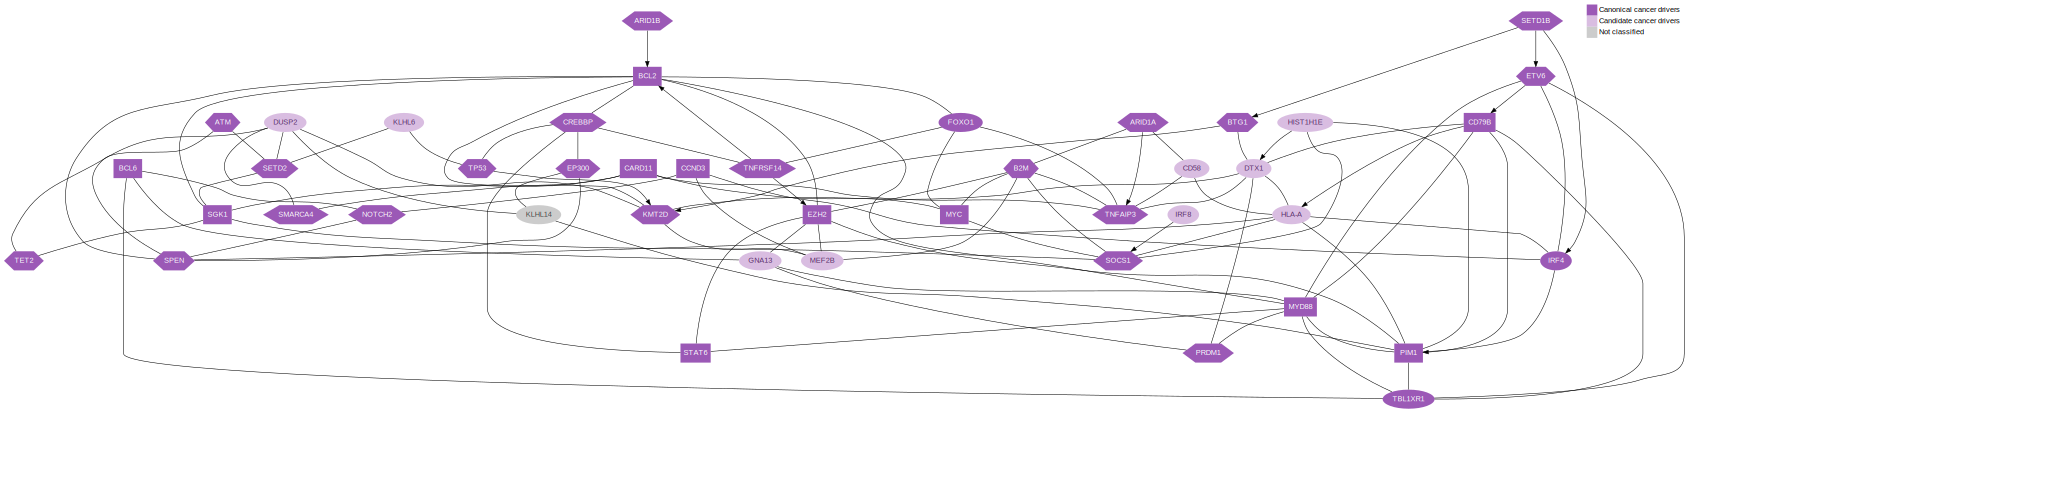

In [ ]:
from causallearn.search.ConstraintBased.FCI import fci

# Running the Fast Causal Inference (FCI) algorithm for causal discovery
causal_graph_fci, edges = fci(data_matrix, node_names=genes_labels)
dot_graph_convert_edges_fci, edges_converted_fci = convert_edges_FCI(causal_graph_fci)

# Graph legend items
legend_graph = [("#9B59B6", "Canonical cancer drivers"), ("#D9BDE1", "Candidate cancer drivers"), ("#CCCCCC", "Not classified")]

# Plotting the graph with the converted edges
plot_causal_graph(dot_graph_convert_edges_fci,
                  file_name=dirs["gene_networks"] + "/1.fci_graph",
                  canonical_drivers=canonical_cancer_drivers, candidate_drivers=candidate_cancer_drivers,
                  oncogene=oncogene_list, tsg=tsg_list, legend=legend_graph)


<br>

### **GES**

Causal graph saved to 'Output/Gene networks/2.ges_graph'






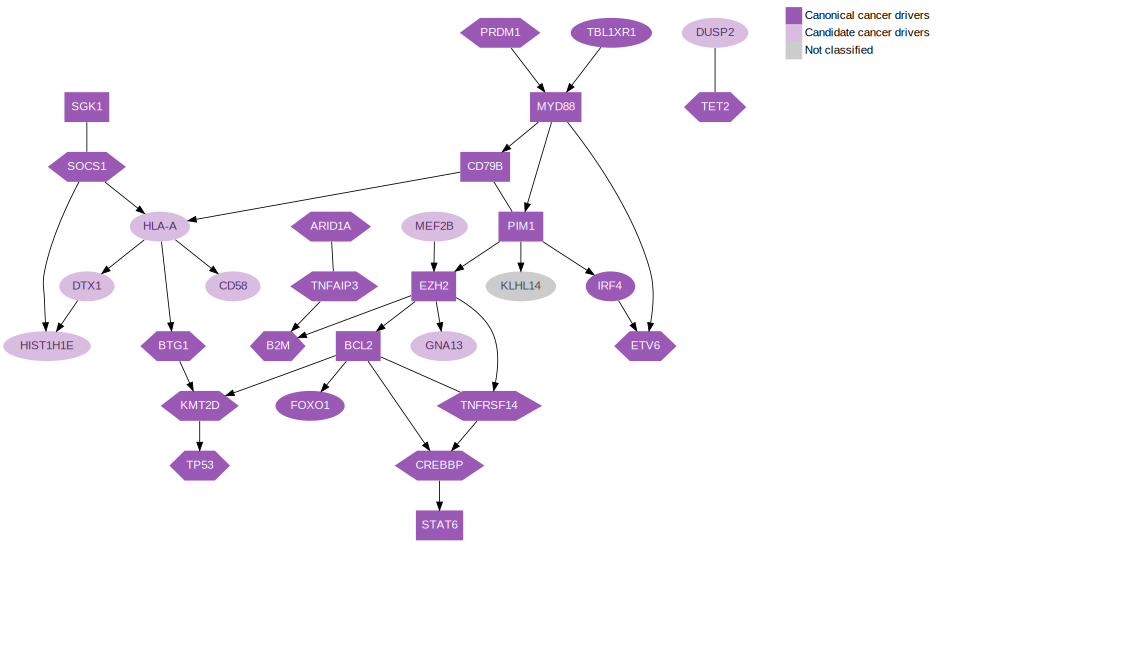

In [ ]:
from causallearn.search.ScoreBased.GES import ges

# Running the Greedy Equivalence Search (GES) algorithm for causal discovery
causal_graph_ges = ges(data_matrix, node_names=genes_labels)

# Plotting and printing the results
plot_causal_graph(causal_graph_ges['G'],
                  file_name=dirs["gene_networks"] + "/2.ges_graph",
                  canonical_drivers=canonical_cancer_drivers, candidate_drivers=candidate_cancer_drivers,
                  oncogene=oncogene_list, tsg=tsg_list, legend=legend_graph)


<br>

### **Consensus graph**


Consensus Graph
   Edges in both graphs (identical): 4
   Edges of different types (directed and undirected): 26
   Edges with opposite directions: 3
Causal graph saved to 'Output/Gene networks/3.consensus_graph'






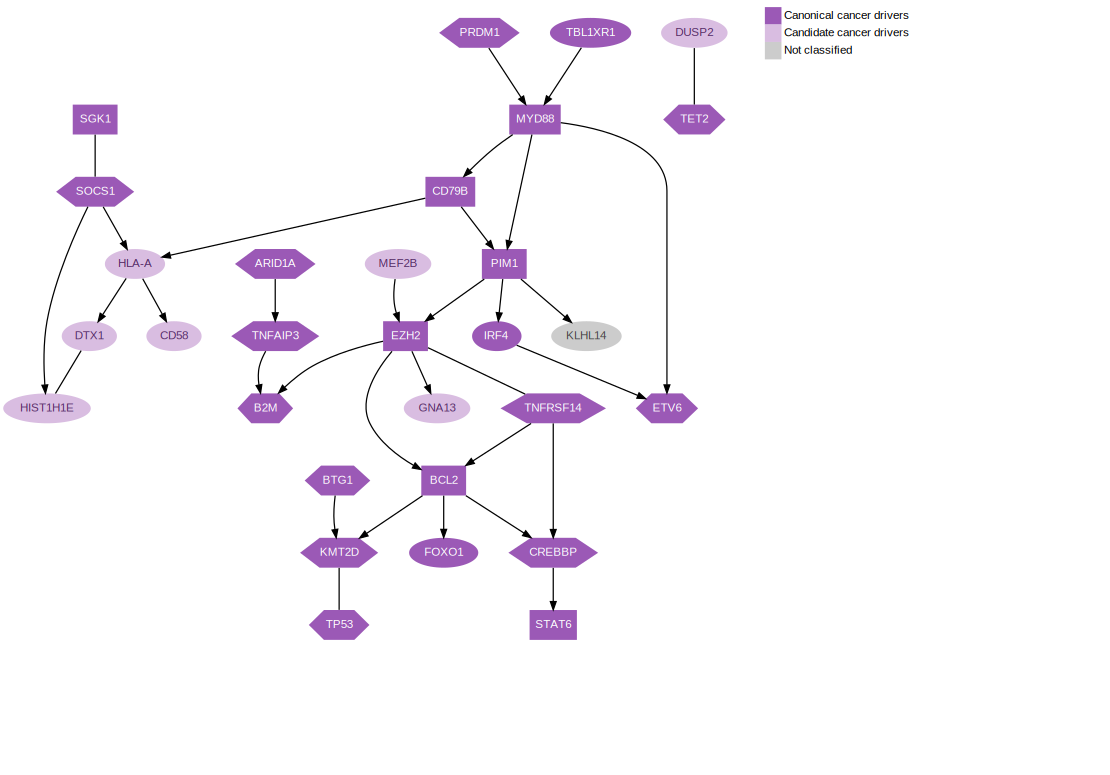

In [ ]:
fci_edges = edges_converted_fci
ges_edges = {str(edge) for edge in causal_graph_ges['G'].get_graph_edges()}

dot_consensus_graph = create_consensus_graph(fci_edges, ges_edges, genes_labels)

plot_causal_graph(dot_consensus_graph,
                  file_name=dirs["gene_networks"] + "/3.consensus_graph",
                  canonical_drivers=canonical_cancer_drivers, candidate_drivers=candidate_cancer_drivers,
                  oncogene=oncogene_list, tsg=tsg_list, legend=legend_graph,
                  nodesep=0.5, ranksep=0.5)


<br><br><br>
<br><br><br>

---


# **7) Characterize network**

- The edges of causal graphs are classified in three ways:
  * **Edge color**: co-occurrence or mutual exclusivity
  * **Edge thickness**: based on the p-value
  * **Style (dashed)**: if it is in the known gene network


<br>

### **Functions**


In [ ]:
# Function to classify the edges of causal graphs as "co-occurrence" and "mutual exclusivity"

def classify_graph_edges(cg, binary_data_df, known_network_df=None, cooccurrence_threshold=1.0, exclusion_threshold=1.0):

    # Define the set of edges of the known gene network
    known_edges_set = set()
    if known_network_df is not None:
        for _, row in known_network_df.iterrows():
            g1, g2 = str(row['Gene1']).strip(), str(row['Gene2']).strip()
            edge_key = tuple(sorted((g1, g2)))
            known_edges_set.add(edge_key)

    # Prepare the pydot object
    if isinstance(cg, GeneralGraph):
        cg_dot = GraphUtils.to_pydot(cg)
        original_nodes = cg.get_nodes()
        node_map = {i: node.get_name() for i, node in enumerate(original_nodes)}
    elif isinstance(cg, pydot.Dot):
        cg_dot = copy.deepcopy(cg)
    else:
        raise ValueError("You need to provide a valid 'cg' object.")

    # Get the edges of the causal graph
    causal_graph_edges = cg_dot.get_edges()

    # Number of edges that have been colored in the causal graph
    edges_modified = 0

    # List to store data for the DataFrame
    edges_data_list = []

    # Iterate over the edges of the graph
    for edge in causal_graph_edges:
        # Get the names of the genes from the edge
        if isinstance(cg, GeneralGraph):
            source_name = node_map.get(edge.get_source())
            destination_name = node_map.get(edge.get_destination())
        else:
            source_name = edge.get_source().strip('"')
            destination_name = edge.get_destination().strip('"')

        # Statistical test (Fisher)
        contingency_table = pd.crosstab(binary_data_df[source_name], binary_data_df[destination_name])
        odds_ratio, p_value = fisher_exact(contingency_table)

        # Reset default style/color
        edge.set_color("gray40")
        edge.set_style("solid") # Garante que comece sólida
        edge_type = "Not significant"

        # If the association is statistically significant
        if p_value < 0.05:
            if odds_ratio >= cooccurrence_threshold:
                edge.set_color("dodgerblue3")
                edge_type = "Co-occurrence"
                edges_modified += 1
            elif odds_ratio <= exclusion_threshold:
                edge.set_color("firebrick3")
                edge_type = "Mutual exclusivity"
                edges_modified += 1
            else:
                edge_type = "Neutral"


        # Define thickness based on the p-value.
        if p_value < 0.001:
            line_width = "3.0"
        else:
            line_width = "1.0"
        edge.set_penwidth(line_width)

        # Create an ordered key for the current edge of the graph
        current_edge_key = tuple(sorted((source_name, destination_name)))

        is_known = False
        if current_edge_key in known_edges_set:
            edge.set_style("dashed")
            is_known = True

        # Add data to the list
        edges_data_list.append({
            "Gene1": source_name,
            "Gene2": destination_name,
            "EdgeDirection": "-->" if edge.get_dir() == "forward" else "---",
            "EdgeType": edge_type,
            "pValue": p_value,
            "InKnownNetwork": is_known
        })

    print(f"Total edges classified based on Fisher Test: {edges_modified}")

    # Create DataFrame
    edges_df = pd.DataFrame(edges_data_list)

    # Return both the graph and the dataframe
    return cg_dot, edges_df


<br>

In [ ]:
# Function to compare the edges of the causal graph with the edges of a gene network

def analyze_graph_edges(graph_edges, gene_network):
    # Create the search map
    known_edges_map = {}
    for index, row in gene_network.iterrows():
        key = tuple(sorted([str(row["Gene1"]), str(row["Gene2"])]))
        edge_type = row["EdgeType"]

        if key not in known_edges_map:
            known_edges_map[key] = set()
        known_edges_map[key].add(edge_type)

    # Lists for storing the edges found
    edges_same_type_list = []
    edges_diff_type_list = []

    # Compare the edges
    for index, row in graph_edges.iterrows():
        generated_key = tuple(sorted([str(row["Gene1"]), str(row["Gene2"])]))
        generated_type = row["EdgeType"]
        gene1, gene2 = row["Gene1"], row["Gene2"]

        if generated_key in known_edges_map:
            known_types = known_edges_map[generated_key]
            edge_str = f"{gene1} - {gene2}"

            if generated_type in known_types:
                edges_same_type_list.append(f"{edge_str} (Type: {generated_type})")
            else:
                known_types_str = ", ".join(known_types)
                edges_diff_type_list.append(f"{edge_str} (Type in the causal graph: {generated_type} | Type in the gene network: {known_types_str})")


    print("SUMMARY:")
    print(f"   • Number of edges in the generated graph: {len(graph_edges)}")
    print(f"   • Number of edges in 'known network' with the same type: {len(edges_same_type_list)}")
    print(f"   • Number of edges in 'known network' with different types: {len(edges_diff_type_list)}")


    print(f"\nEDGES OF THE SAME TYPE ({len(edges_same_type_list)} edges):")
    if edges_same_type_list:
        for item in edges_same_type_list:
            print(f"   • {item}")
    else:
        print("   • (No edges found in this category)")


    print(f"\nEDGES OF DIFFERENT TYPES ({len(edges_diff_type_list)} edges):")
    if edges_diff_type_list:
        for item in edges_diff_type_list:
            print(f"   • {item}")
    else:
        print("   • (No edges found in this category)")

    print("\n\n")


<br>

In [ ]:
# Function to define the color palette of subtypes

def get_subtype_colors(auto_calculate=False):
    if (auto_calculate):
        # Identify all unique subtypes in the file
        unique_subtypes = sorted(dlbcl_genetic_subtypes_df["Subtype"].unique())

        # Generate a palette of distinct colors (one for each subtype)
        palette = sns.color_palette("Set2", len(unique_subtypes)).as_hex()

        # Create dictionary {Subtype: Color}
        subtype_colors = dict(zip(unique_subtypes, palette))

    else:
        subtype_colors = {"A53": "#66C2A5", "BN2": "#FC8D62", "EZB": "#7B91C3",
                          "MCD": "#E78AC3", "N1": "#AA72D4", "ST2": "#FF6565"}

    return subtype_colors


<br>

In [ ]:
# Function to generate a graph with comparisons to known datasets

def plot_causal_graph_subtypes(cg, subtypes_df, title="Causal Graph by Subtypes",
                               oncogene=None, tsg=None,
                               remove_unconnected_nodes=True, display_graph=True,
                               file_name="causal_graph_subtypes",
                               nodesep=0.5, ranksep=0.5):

    # Generate a palette of distinct colors (one for each subtype)
    subtype_colors = get_subtype_colors()

    # Create a dictionary {Gene: Subtype} for quick searching
    gene_to_subtype = dict(zip(subtypes_df["Gene"], subtypes_df["Subtype"]))

    # Graph Preparation (pydot)
    if isinstance(cg, GeneralGraph):
        cg_dot = GraphUtils.to_pydot(cg)
        original_nodes = cg.get_nodes()
        node_map = {i: node.get_name() for i, node in enumerate(original_nodes)}
    elif isinstance(cg, pydot.Dot):
        cg_dot = copy.deepcopy(cg)
        node_map = None
    else:
        raise ValueError("The 'cg' object must be a GeneralGraph or pydot.Dot")

    # Filtering of disconnected nodes
    connected_nodes = set()
    if remove_unconnected_nodes:
        for edge in cg_dot.get_edges():
            connected_nodes.add(edge.get_source().strip('"'))
            connected_nodes.add(edge.get_destination().strip('"'))

    used_subtypes = set()
    has_unclassified = False

    # Applying colors to the nodes
    for node in cg_dot.get_nodes():
        # Ignore legend nodes or internal tables
        node_id_raw = node.get_name()
        if node_id_raw.startswith("legend") or node_id_raw.startswith("<<table"):
            continue

        # Get the gene name
        if node_map:
            gene_name = node_map.get(int(node_id_raw))
        else:
            gene_name = node.get_attributes().get("label", node_id_raw).strip('"')

        # Remove disconnected nodes
        if remove_unconnected_nodes and (node_id_raw.strip('"') not in connected_nodes) and (gene_name not in connected_nodes):
            cg_dot.del_node(node_id_raw)
            continue

        # Style the node
        node.set_style("filled")
        node.set_fontname("Helvetica")
        node.set_color("transparent")


        # Defining the shape of the node (oncogene or tumor suppressor)
        if (oncogene is not None) and (gene_name in oncogene):
            node.set_shape("box")
        elif (tsg is not None) and (gene_name in tsg):
            node.set_shape("hexagon")

        # Check the subtype and apply the color
        if gene_name in gene_to_subtype:
            subtype = gene_to_subtype[gene_name]
            used_subtypes.add(subtype)
            color = subtype_colors.get(subtype, "#CCCCCC")
            node.set_fillcolor(color)
            node.set_fontcolor("white")
        else:
            has_unclassified = True
            node.set_fillcolor("#CCCCCC")
            node.set_fontcolor("#484848")

    # Add graph legend
    legend_items = []
    for subtype, color in subtype_colors.items():
        if subtype in used_subtypes:
            legend_items.append((color, subtype))

    if has_unclassified:
        legend_items.append(("#CCCCCC", "Not classified"))

    legend_node = create_legend(legend_items)
    cg_dot.add_node(legend_node)

    # Saving the graph
    cg_dot.set_graph_defaults(dpi="200", nodesep=str(nodesep), ranksep=str(ranksep))
    cg_dot.write_png(file_name + ".png")
    cg_dot.write_pdf(file_name + ".pdf")

    print(f"\nGraph saved in: '{file_name}'")

    # Display
    if display_graph:
        cg_dot.set_graph_defaults(dpi="60", nodesep=str(nodesep), ranksep=str(ranksep))
        img_svg = SVG(cg_dot.create_svg())
        print("\n")
        display(img_svg)

    return cg_dot


<br>

### **Characterize edges**

Total edges classified based on Fisher Test: 33
Causal graph saved to 'Output/Gene networks/4.consensus_graph_with_classified_edges'






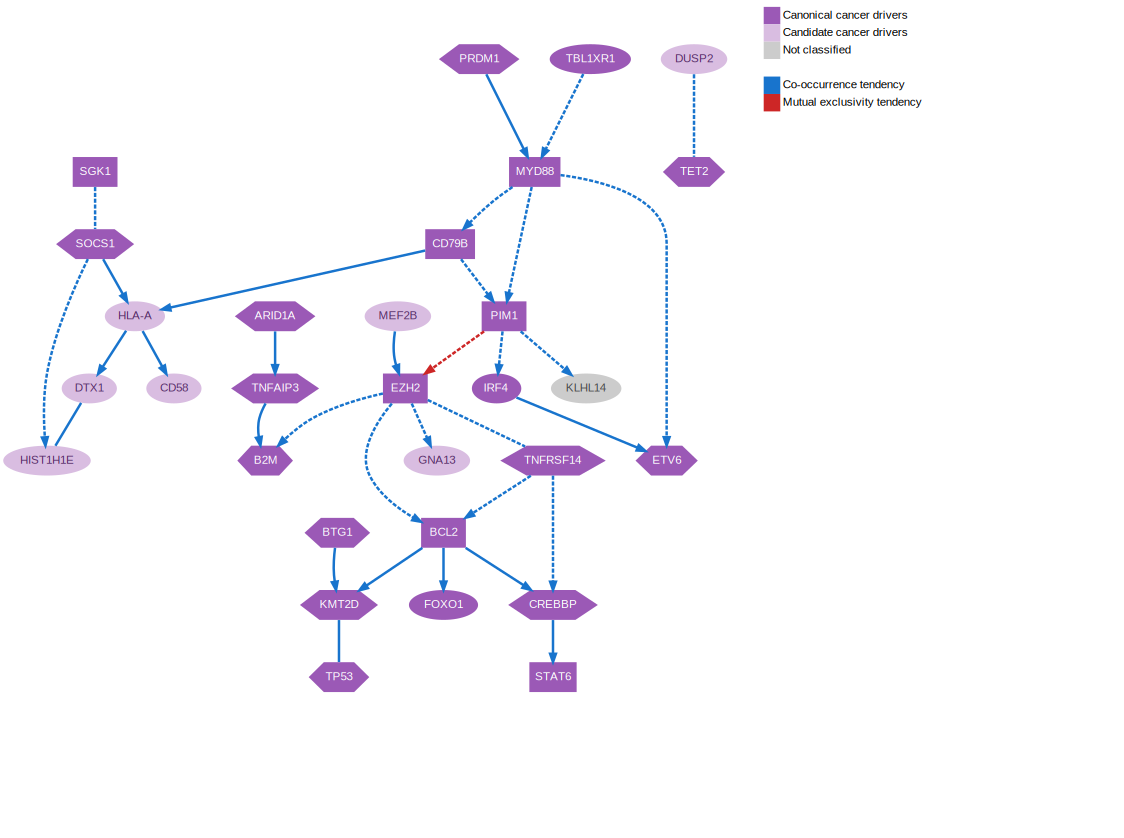

In [ ]:
# Classify the edges of the causal graph
dot_consensus_graph_classified_edges, edges_classified_edges = classify_graph_edges(dot_consensus_graph, binary_data_df, dlbcl_gene_network_df)


# Graph legend items
legend_graph_classified_edges = [("#9B59B6", "Canonical cancer drivers"), ("#D9BDE1", "Candidate cancer drivers"), ("#CCCCCC", "Not classified"),
     ("#FFFFFF", " "), ("dodgerblue3", "Co-occurrence tendency"), ("firebrick3", "Mutual exclusivity tendency")]

# Plotting the graph with the classified edges
plot_causal_graph(dot_consensus_graph_classified_edges,
                  file_name=dirs["gene_networks"] + "/4.consensus_graph_with_classified_edges",
                  canonical_drivers=canonical_cancer_drivers, candidate_drivers=candidate_cancer_drivers,
                  oncogene=oncogene_list, tsg=tsg_list, legend=legend_graph_classified_edges)

# Save the dataframe with the graph edges to a TSV file
edges_classified_edges.to_csv(dirs["tables"] + "/edges_consensus_graph.tsv", sep="\t", index=False)



<br>

In [ ]:
# Comparison of the edges of the causal graph with the edges of the gene network from the paper "Genetic and Functional Drivers of Diffuse Large B Cell Lymphoma" (Reddy, 2017)
analyze_graph_edges(edges_classified_edges, dlbcl_gene_network_df)


SUMMARY:
   • Number of edges in the generated graph: 33
   • Number of edges in 'known network' with the same type: 17
   • Number of edges in 'known network' with different types: 0

EDGES OF THE SAME TYPE (17 edges):
   • SGK1 - SOCS1 (Type: Co-occurrence)
   • DUSP2 - TET2 (Type: Co-occurrence)
   • EZH2 - B2M (Type: Co-occurrence)
   • EZH2 - BCL2 (Type: Co-occurrence)
   • TNFRSF14 - BCL2 (Type: Co-occurrence)
   • EZH2 - GNA13 (Type: Co-occurrence)
   • TNFRSF14 - CREBBP (Type: Co-occurrence)
   • MYD88 - ETV6 (Type: Co-occurrence)
   • PIM1 - EZH2 (Type: Mutual exclusivity)
   • PIM1 - KLHL14 (Type: Co-occurrence)
   • PIM1 - IRF4 (Type: Co-occurrence)
   • TBL1XR1 - MYD88 (Type: Co-occurrence)
   • CD79B - PIM1 (Type: Co-occurrence)
   • SOCS1 - HIST1H1E (Type: Co-occurrence)
   • MYD88 - CD79B (Type: Co-occurrence)
   • MYD88 - PIM1 (Type: Co-occurrence)
   • EZH2 - TNFRSF14 (Type: Co-occurrence)

EDGES OF DIFFERENT TYPES (0 edges):
   • (No edges found in this category)





<br>

### **Characterize nodes**




Graph saved in: 'Output/Gene networks/5.consensus_graph_with_subtypes'




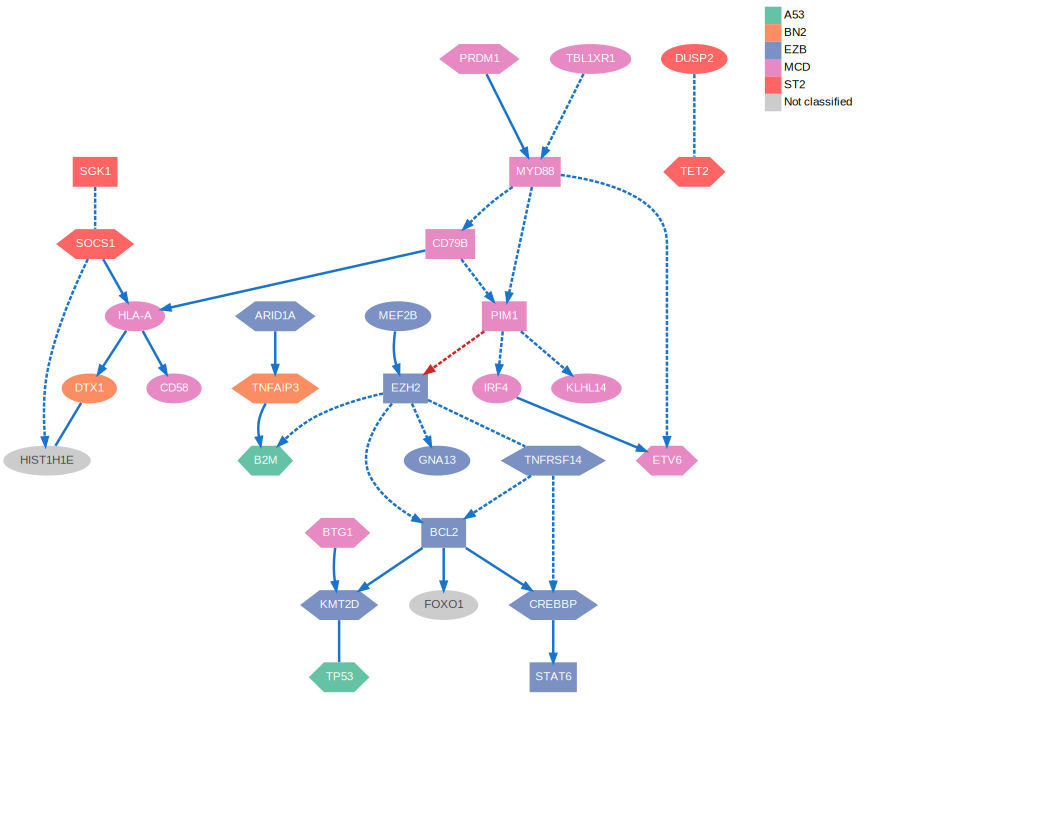

In [ ]:
plot_causal_graph_subtypes(dot_consensus_graph_classified_edges,
                           subtypes_df=dlbcl_genetic_subtypes_df,
                           oncogene=oncogene_list, tsg=tsg_list,
                           file_name=dirs["gene_networks"] + "/5.consensus_graph_with_subtypes")


<br>

In [ ]:
connected_nodes = set()
for edge in dot_consensus_graph_classified_edges.get_edges():
    connected_nodes.add(edge.get_source())
    connected_nodes.add(edge.get_destination())

total_edges = len(dot_consensus_graph_classified_edges.get_edges())
dashed_edges_count = 0

for edge in dot_consensus_graph_classified_edges.get_edges():
    if edge.get_style() == "dashed":
        dashed_edges_count += 1

print(f"Quantidade de nós com 1 ou mais arestas: {len(connected_nodes)}")
print(f"Total de arestas no grafo: {total_edges}")
print(f"Quantidade de arestas tracejadas: {dashed_edges_count}")


Quantidade de nós com 1 ou mais arestas: 30
Total de arestas no grafo: 33
Quantidade de arestas tracejadas: 17


<br><br><br>
<br><br><br>

---


# **8) Supplementary plots**


<br>

### **Functions**


In [ ]:
# Function to identify connected genes and prepare the categorical mutation matrix

def prepare_mutation_data(edges_df, samples_df, maf_df):
    # Identify connected genes
    connected_genes = pd.unique(
        edges_df[['Gene1', 'Gene2']].values.ravel('K')
    )

    # Filter the MAF file
    valid_samples = samples_df.index
    heatmap_source_df = maf_df[
        (maf_df["Hugo_Symbol"].isin(connected_genes)) &
        (maf_df["Tumor_Sample_Barcode"].isin(valid_samples))
    ].copy()

    # Create pivot table with Variant_Type
    mutations_categorical_df = heatmap_source_df.pivot_table(
        index="Tumor_Sample_Barcode",
        columns="Hugo_Symbol",
        values="Variant_Type",
        aggfunc='first'
    )

    # Reindex and fill missing values (Wild Type)
    mutations_categorical_df = mutations_categorical_df.reindex(index=valid_samples, columns=connected_genes)
    wild_type_label = "No Mutation"
    mutations_categorical_df = mutations_categorical_df.fillna(wild_type_label)

    return mutations_categorical_df, wild_type_label


<br>

In [ ]:
# Function to create color maps and convert the categorical matrix into a numeric matrix for the heatmap

def map_variant_colors(mutations_categorical_df, wild_type_label="No Mutation"):

    unique_variants = sorted(list(set([v for v in mutations_categorical_df.values.ravel() if v != wild_type_label])))

    # Ordering the types of variants
    custom_order = ["SNP", "DNP", "TNP", "ONP", "INS", "DEL"]
    order_index = {variant: index for index, variant in enumerate(custom_order)}
    sorted_variants = sorted(
        unique_variants,
        key=lambda variant: order_index.get(variant, len(order_index))
    )

    # Create color palette
    variant_palette = sns.color_palette("bright", len(sorted_variants)).as_hex()
    variant_color_map = dict(zip(sorted_variants, variant_palette))
    variant_color_map[wild_type_label] = "#E0E0E0"

    # Convert variants to numbers
    variant_to_num_map = {v: i+1 for i, v in enumerate(unique_variants)}
    variant_to_num_map[wild_type_label] = 0
    num_to_variant_map = {v: k for k, v in variant_to_num_map.items()}

    # Create numeric matrix (infer_objects used to handle future pandas behavior)
    pd.set_option("future.no_silent_downcasting", True)
    numeric_heatmap_df = mutations_categorical_df.replace(variant_to_num_map).infer_objects(copy=False)

    return numeric_heatmap_df, variant_color_map, num_to_variant_map, sorted_variants


<br>

In [ ]:
# Function to sort genes by subtype/frequency and samples by presence

def sort_genes_and_samples(numeric_heatmap_df, subtypes_df=None):
    # Create auxiliary DataFrame to calculate gene order
    gene_order_info = pd.DataFrame(index=numeric_heatmap_df.columns)

    # Calculate mutation frequency (used as a tiebreaker within groups)
    gene_order_info["Mutation_Count"] = (numeric_heatmap_df != 0).sum()

    if subtypes_df is not None:
        # Genes in subtypes_df will be ordered as they appear in subtypes_df
        subtype_genes_in_order = subtypes_df["Gene"].unique()
        gene_to_subtype_order = {gene: i for i, gene in enumerate(subtype_genes_in_order)}

        # Assign a primary sorting order: explicit order from subtypes_df for matched genes,
        # and a large value for genes not in subtypes_df to push them to the end.
        gene_order_info["Custom_Primary_Order"] = gene_order_info.index.map(gene_to_subtype_order)
        # Genes not in subtypes_df get a value larger than any explicit order
        gene_order_info["Custom_Primary_Order"] = gene_order_info["Custom_Primary_Order"].fillna(
            len(subtype_genes_in_order) # This value will be the first "slot" after explicitly ordered genes
        )

        # Map subtypes from the provided df for secondary sorting criteria
        subtype_map = dict(zip(subtypes_df["Gene"], subtypes_df["Subtype"]))
        gene_order_info['Subtype'] = gene_order_info.index.map(subtype_map)

        # Fill genes without a subtype (those not in subtypes_df or with no subtype info) as "Unclassified"
        gene_order_info["Subtype"] = gene_order_info["Subtype"].fillna("Unclassified")

        # Calculate the size of each subtype (to place larger groups at the top for secondary sorting)
        subtype_counts = gene_order_info["Subtype"].value_counts()
        gene_order_info["Subtype_Size"] = gene_order_info["Subtype"].map(subtype_counts)

        # Define flag to push 'Unclassified' genes to the end within their groups (secondary sorting)
        gene_order_info["Is_Classified"] = (gene_order_info["Subtype"] != "Unclassified").astype(int)

        # Priority order:
        #   a) Is_Classified (within genes not explicitly ordered, "classified" genes come before "Unclassified")
        #   b) Subtype_Size (Larger groups first)
        #   c) Custom_Primary_Order (genes from subtypes_df first, in their original order)
        #   d) Subtype (Alphabetical order of subtype names)
        #   e) Mutation_Count (Most mutated genes first)
        gene_order_info = gene_order_info.sort_values(
            by=["Is_Classified", "Subtype_Size", "Custom_Primary_Order", "Subtype", "Mutation_Count"],
            ascending=[False, False, True, True, False]
        )

        # Apply new order to the numeric matrix columns
        #sorted_genes = gene_order_info.index.tolist()
        #numeric_heatmap_df = numeric_heatmap_df[sorted_genes]

    else:
        # Original logic if no subtypes_df is provided.
        # This branch ensures the function behaves as before if subtypes_df is None.
        print("WARNING: 'subtypes_df' not provided. Using frequency only.")
        gene_order_info["Subtype"] = np.nan
        gene_order_info["Subtype"] = gene_order_info["Subtype"].fillna("Unclassified")

        # Calculate the size of each subtype (to place larger groups at the top)
        subtype_counts = gene_order_info["Subtype"].value_counts()
        gene_order_info["Subtype_Size"] = gene_order_info["Subtype"].map(subtype_counts)

        # Define flag to push 'Unclassified' to the end
        # True (1) if classified, False (0) if Unclassified
        gene_order_info["Is_Classified"] = (gene_order_info["Subtype"] != "Unclassified").astype(int)

        # Priority order (original):
        #   a) Classified (Classified first)
        #   b) Subtype Size (Larger groups first)
        #   c) Subtype Name
        #   d) Mutation Frequency (Most mutated genes first)
        gene_order_info = gene_order_info.sort_values(
            by=["Is_Classified", "Subtype_Size", "Subtype", "Mutation_Count"],
            ascending=[False, False, True, False]
        )

    # Apply new order to the numeric matrix columns
    sorted_genes = gene_order_info.index.tolist()
    numeric_heatmap_df = numeric_heatmap_df[sorted_genes]

    # Sort samples (rows) to group visually (waterfall/cascade effect)
    numeric_heatmap_df = numeric_heatmap_df.sort_values(by=list(numeric_heatmap_df.columns), ascending=False)

    # Transpose for the heatmap (Rows=Genes, Columns=Samples)
    heatmap_final_df = numeric_heatmap_df.T

    return heatmap_final_df, gene_order_info


<br>

In [ ]:
# Function to generate, format, and save the heatmap graph.

def plot_mutational_status_heatmap(heatmap_final_df, gene_order_info, variant_color_map,
                           num_to_variant_map, unique_variants, wild_type_label,
                           subtype_colors_dict, output_path=None, plot_titles=False):

    # Heatmap Color Configuration
    sorted_colors = [variant_color_map[num_to_variant_map[i]] for i in range(len(variant_color_map))]
    custom_cmap = mcolors.ListedColormap(sorted_colors)

    # Spaced data (visual hack to separate cells or adjust aspect ratio)
    data = heatmap_final_df.values
    spaced_data = np.full((data.shape[0]*2-1, data.shape[1]), np.nan)
    spaced_data[::2, :] = data

    # Dynamic figure height based on number of genes
    graph_height = (len(heatmap_final_df) * 0.25) + 3
    fig, ax = plt.subplots(figsize=(16, graph_height))

    sns.heatmap(spaced_data, cmap=custom_cmap, cbar=False, yticklabels=False, xticklabels=False,
                vmin=0, vmax=len(unique_variants))

    if plot_titles:
        plt.title("Mutational status", fontsize=16, pad=20)
        plt.ylabel("Genes", fontsize=14, labelpad=10)
        plt.xlabel("Tumor samples", fontsize=14, labelpad=15)

    # Configure Y-axis Ticks
    ticks_pos = np.arange(0, spaced_data.shape[0], 2) + 0.5
    plt.yticks(ticks=ticks_pos, labels=heatmap_final_df.index, rotation=0, fontsize=10)

    # Color Y-axis Labels based on Subtype
    ylabels = ax.get_yticklabels()
    for label in ylabels:
        gene_name = label.get_text()
        # Safe lookup for subtype
        if gene_name in gene_order_info.index:
            subtype = gene_order_info.loc[gene_name, "Subtype"]
            label.set_color(subtype_colors_dict.get(subtype, "black"))
            if subtype != "Unclassified":
                label.set_fontweight("bold")

    # Legend
    legend_elements = []
    for variant in unique_variants:
        legend_elements.append(Patch(facecolor=variant_color_map[variant], edgecolor="gray", label=variant))

    ax.legend(handles=legend_elements, title="Variant type", title_fontsize=12,
              bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0.)

    plt.tight_layout(rect=[0, 0, 0.9, 1])

    if output_path:
        plt.savefig(output_path + ".png", dpi=300, bbox_inches="tight")
        plt.savefig(output_path + ".pdf", format="pdf", bbox_inches="tight")
        print(f"Plot saved to: '{output_path}'\n\n")

    plt.show()


<br>

In [ ]:
# Function for formatting heatmap labels

def format_axis_labels(labels, subtype_colors):
    for label in labels:
        gene_name = label.get_text()
        if gene_name in gene_order_info.index:
            subtype = gene_order_info.loc[gene_name, "Subtype"]
            label.set_color(subtype_colors.get(subtype, "black"))
            if subtype != "Unclassified":
                label.set_fontweight("bold")


<br>

### **Mutational status of genes**

* Creating a graph with mutations per gene in each tumor sample

Plot saved to: 'Output/Graphs/mutational_status_of_subtypes'




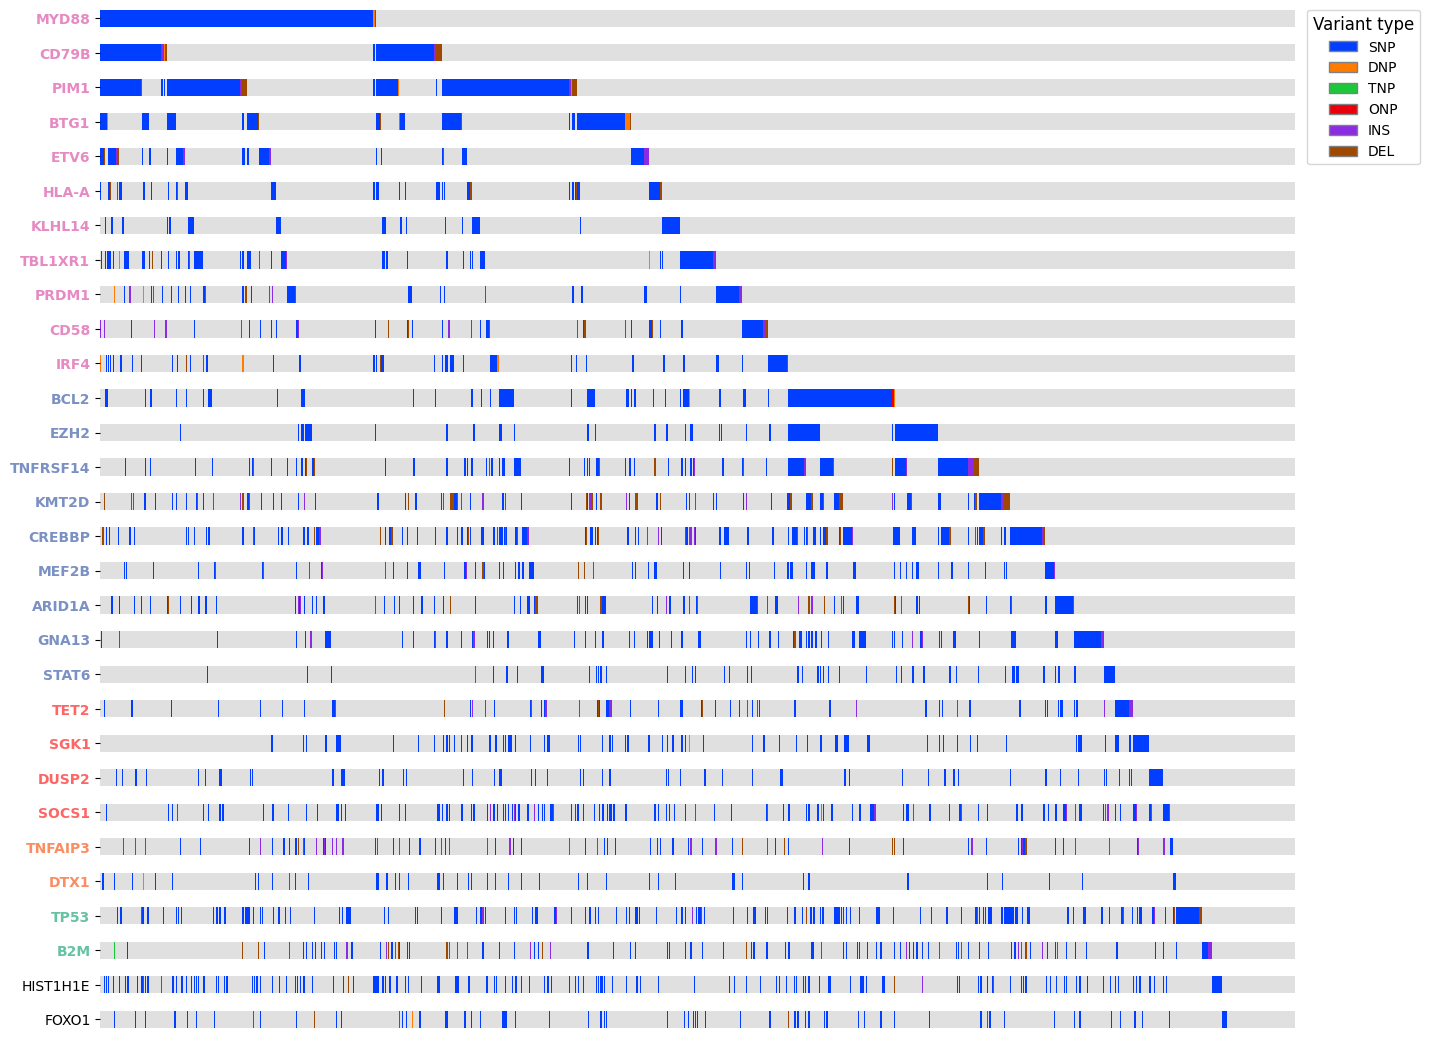

In [ ]:
# Preparation of mutation data
mutations_categorical_df, wild_type_label = prepare_mutation_data(edges_classified_edges, binary_data_df, maf_df)

# Color mpping
numeric_heatmap_df, variant_color_map, num_to_variant_map, unique_variants = map_variant_colors(mutations_categorical_df, wild_type_label)

# Sorting the genes
heatmap_final_df, gene_order_info = sort_genes_and_samples(numeric_heatmap_df, dlbcl_genetic_subtypes_df)

# Plotting the heatmap
subtype_colors = get_subtype_colors()
plot_mutational_status_heatmap(heatmap_final_df, gene_order_info, variant_color_map,
                               num_to_variant_map, unique_variants, wild_type_label, subtype_colors,
                               output_path=dirs["graphs"] + "/mutational_status_of_subtypes")


<br>

### **Gene correlation**


Plot saved to: 'Output/Graphs/gene_correlation_heatmap'




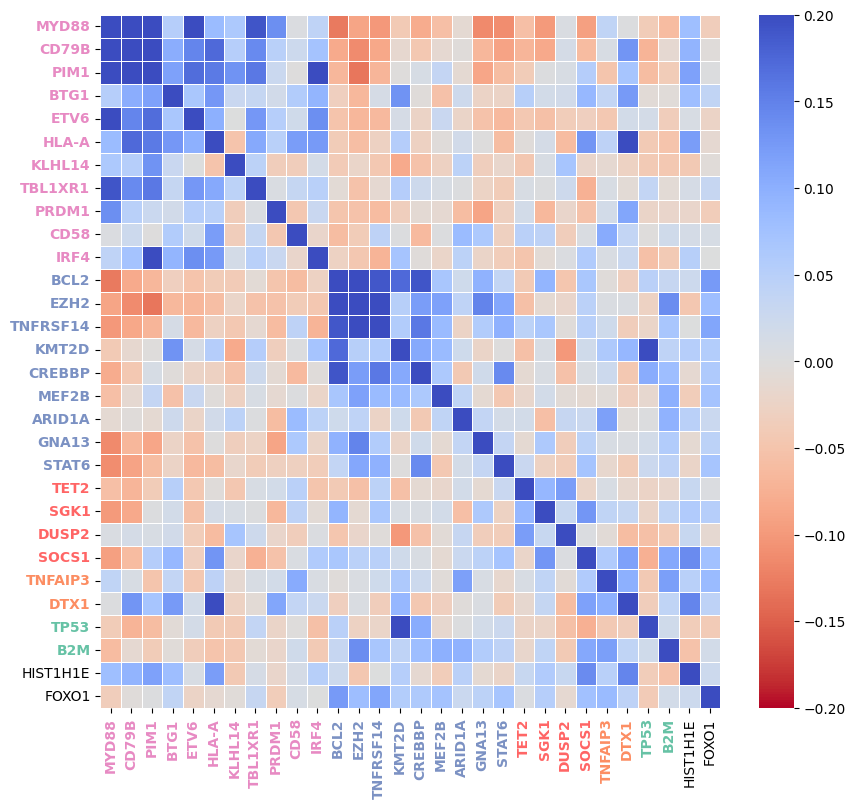

In [ ]:
gene_order_list = gene_order_info.index.tolist()

graph_data_df = binary_data_df.copy()
graph_data_df = graph_data_df[gene_order_list]

# Calculate the Pearson correlation matrix
pearson_corr_matrix = graph_data_df.corr(method="pearson")

plt.figure(figsize=(10, 9))

# Generate the Heatmap
heatmap_pearson = sns.heatmap(pearson_corr_matrix, cmap="coolwarm_r",
                              annot=False, linewidths=.5, vmin=-0.2, vmax=0.2)

# Format titles
heatmap_pearson.set_xlabel("")
heatmap_pearson.set_ylabel("")

# Format heatmap labels
subtype_colors = get_subtype_colors()
format_axis_labels(heatmap_pearson.get_yticklabels(), subtype_colors)
format_axis_labels(heatmap_pearson.get_xticklabels(), subtype_colors)

# Save heapmap as PNG file
output_path = dirs["graphs"] + "/gene_correlation_heatmap"
print(f"Plot saved to: '{output_path}'\n\n")
plt.savefig(output_path + ".png", dpi=300, bbox_inches="tight")
plt.savefig(output_path + ".pdf", format="pdf", bbox_inches="tight")

plt.show()


<br><br><br>
<br><br><br>

---


# **9) Exporting results**

- This section allows the user to download the Output folder, which contains the graphs generated by the pipeline.

- The folder is first compressed into a .zip file, then a download button is displayed.

- By clicking the button, the zipped folder will be downloaded directly to the user’s computer.

In [ ]:
import shutil
import ipywidgets as widgets
from IPython.display import display
from google.colab import files

# Function to download the zip file
def on_download_button_clicked(b):
    files.download("Output.zip")

# Compact the Output folder
shutil.make_archive("Output", 'zip', "Output")

# Create download button
download_button = widgets.Button(description="Download Output", button_style='success')
download_button.on_click(on_download_button_clicked)
display(download_button)


Button(button_style='success', description='Download Output', style=ButtonStyle())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>